In [3]:
import pandas as pd
df=pd.read_csv("C:\\Users\\Dell\\Downloads\\Job_Market_Dataset.csv")
df

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time
5,6,Data Analyst,Data,Hyderabad,2024,Deloitte,1,4,9,Full-Time
6,7,Data Scientist,Data,Pune,2025,Amazon,3,12,25,Full-Time
7,8,AI Engineer,AI/ML,Bangalore,2025,Microsoft,3,18,35,Full-Time
8,9,SQL Developer,Database,Chennai,2023,HCL,1,3,7,Full-Time
9,10,Python Developer,Software,Hyderabad,2023,Tech Mahindra,2,5,10,Full-Time


### DATA EXPLORATION

In [6]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [8]:
df.tail()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
35,36,Data Scientist,Data,Chennai,2024,Freshworks,2,8,16,Full-Time
36,37,Business Analyst,Business,Delhi,2025,Amazon,3,9,18,Full-Time
37,38,SQL Developer,Database,Pune,2024,Infosys,1,4,8,Full-Time
38,39,Data Analyst,Data,Bangalore,2024,PhonePe,1,6,12,Full-Time
39,40,ML Engineer,AI/ML,Hyderabad,2025,Tesla,4,18,32,Full-Time


In [10]:
df.shape

(40, 10)

In [12]:
df.dtypes

Job_ID                       int64
Job_Title                      str
Job_Category                   str
Location                       str
Year                         int64
Company                        str
Experience_Required_Years    int64
Salary_Min_LPA               int64
Salary_Max_LPA               int64
Employment_Type                str
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Job_ID                     40 non-null     int64
 1   Job_Title                  40 non-null     str  
 2   Job_Category               40 non-null     str  
 3   Location                   40 non-null     str  
 4   Year                       40 non-null     int64
 5   Company                    40 non-null     str  
 6   Experience_Required_Years  40 non-null     int64
 7   Salary_Min_LPA             40 non-null     int64
 8   Salary_Max_LPA             40 non-null     int64
 9   Employment_Type            40 non-null     str  
dtypes: int64(5), str(5)
memory usage: 4.8 KB


In [16]:
df.describe()

,Job_ID,Year,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA
count,40.000000,40.00000,40.000000,40.000000,40.00000
mean,20.500000,2024.07500,2.125000,8.750000,17.32500
std,11.690452,0.79703,1.066687,5.057363,9.41463
min,1.000000,2023.00000,0.000000,3.000000,6.00000
25%,10.750000,2023.00000,1.000000,4.750000,9.75000
50%,20.500000,2024.00000,2.000000,7.000000,15.00000
75%,30.250000,2025.00000,3.000000,11.250000,21.25000
max,40.000000,2025.00000,4.000000,20.000000,40.00000


### DATA CLEANING

### CHECKING FOR NULL VALUES

In [20]:
df.isnull().sum()

Job_ID                       0
Job_Title                    0
Job_Category                 0
Location                     0
Year                         0
Company                      0
Experience_Required_Years    0
Salary_Min_LPA               0
Salary_Max_LPA               0
Employment_Type              0
dtype: int64

### CHECKING DUPLICATE VALUES

In [23]:
df.duplicated().sum()

np.int64(0)

### CHECK FOR OUTLIERS IN NUMERICAL COLUMS

In [26]:
a=df.select_dtypes(include=["int"])

In [28]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)
    IOR=q3-q1
    uw=q3+1.5*IOR
    lw=q1-1.5*IOR
    outliers=((a[i]>uw)|(a[i]<lw))
    print(f"{i}:-",outliers.sum())

Job_ID:- 0
Year:- 0
Experience_Required_Years:- 0
Salary_Min_LPA:- 0
Salary_Max_LPA:- 1


In [30]:
a.loc[outliers,i]=q2
print(((a[i]>uw)|(a[i]<lw)).sum())

0


### data analysis

In [33]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [68]:
a=df.groupby("Location")["Job_Title"].count().sort_values(ascending=False)  #bar chart
a                                        

Location
Bangalore    12
Hyderabad     8
Pune          6
Chennai       5
Mumbai        5
Delhi         4
Name: Job_Title, dtype: int64

### BANGLORE HAS HIGHEST NO. OF JOBS

In [94]:
b=df.groupby("Job_Title")["Salary_Max_LPA"].mean().sort_values(ascending=False).head() #pie chart
b

Job_Title
AI Researcher     40.0
AI Consultant     38.0
AI Engineer       30.5
ML Engineer       25.2
Data Scientist    21.8
Name: Salary_Max_LPA, dtype: float64

### AI RESEAECHER HAS THE HIGHEST AVG SALARY

In [98]:
c=df.groupby("Location")["Salary_Max_LPA"].max().sort_values(ascending=False)  #horizontal bar chart
c

Location
Bangalore    40
Mumbai       38
Hyderabad    32
Chennai      26
Pune         25
Delhi        18
Name: Salary_Max_LPA, dtype: int64

### BANGLORE IS PROVIDING HIGHES SALARY

In [102]:
d=df.groupby("Company")["Salary_Max_LPA"].max().sort_values(ascending=False).head()  #line
d

Company
OpenAI       40
McKinsey     38
Microsoft    35
Meta         35
Tesla        32
Name: Salary_Max_LPA, dtype: int64


### OPEN AI IS PROVIDING MAX SALARY

In [49]:
df.head()

,Job_ID,Job_Title,Job_Category,Location,Year,Company,Experience_Required_Years,Salary_Min_LPA,Salary_Max_LPA,Employment_Type
0,1,Data Analyst,Data,Bangalore,2023,TCS,1,4,8,Full-Time
1,2,Data Scientist,Data,Bangalore,2024,Infosys,2,8,18,Full-Time
2,3,Business Analyst,Business,Hyderabad,2023,Accenture,2,6,12,Full-Time
3,4,ML Engineer,AI/ML,Bangalore,2025,Google,3,15,30,Full-Time
4,5,Power BI Developer,BI,Chennai,2024,Wipro,1,5,10,Full-Time


In [106]:
e=df["Job_Title"].value_counts().head()  #pie
e

Job_Title
Data Analyst        7
Data Scientist      5
Business Analyst    5
ML Engineer         5
Data Engineer       3
Name: count, dtype: int64

### DATA ANALYST HIGHEST NO. OF VACENCIES

In [110]:
f=df.groupby("Job_Title")["Experience_Required_Years"].mean().sort_values(ascending=False).head()  #bar
f 

Job_Title
AI Consultant          4.0
AI Researcher          4.0
AI Engineer            3.0
Data Engineer          3.0
Power BI Consultant    3.0
Name: Experience_Required_Years, dtype: float64

### AI RESEARCHER AND AI CONSULTANT REQUIRE HIGHEST NO. OF EXPERIENCE

### DATA VISUALIZATION

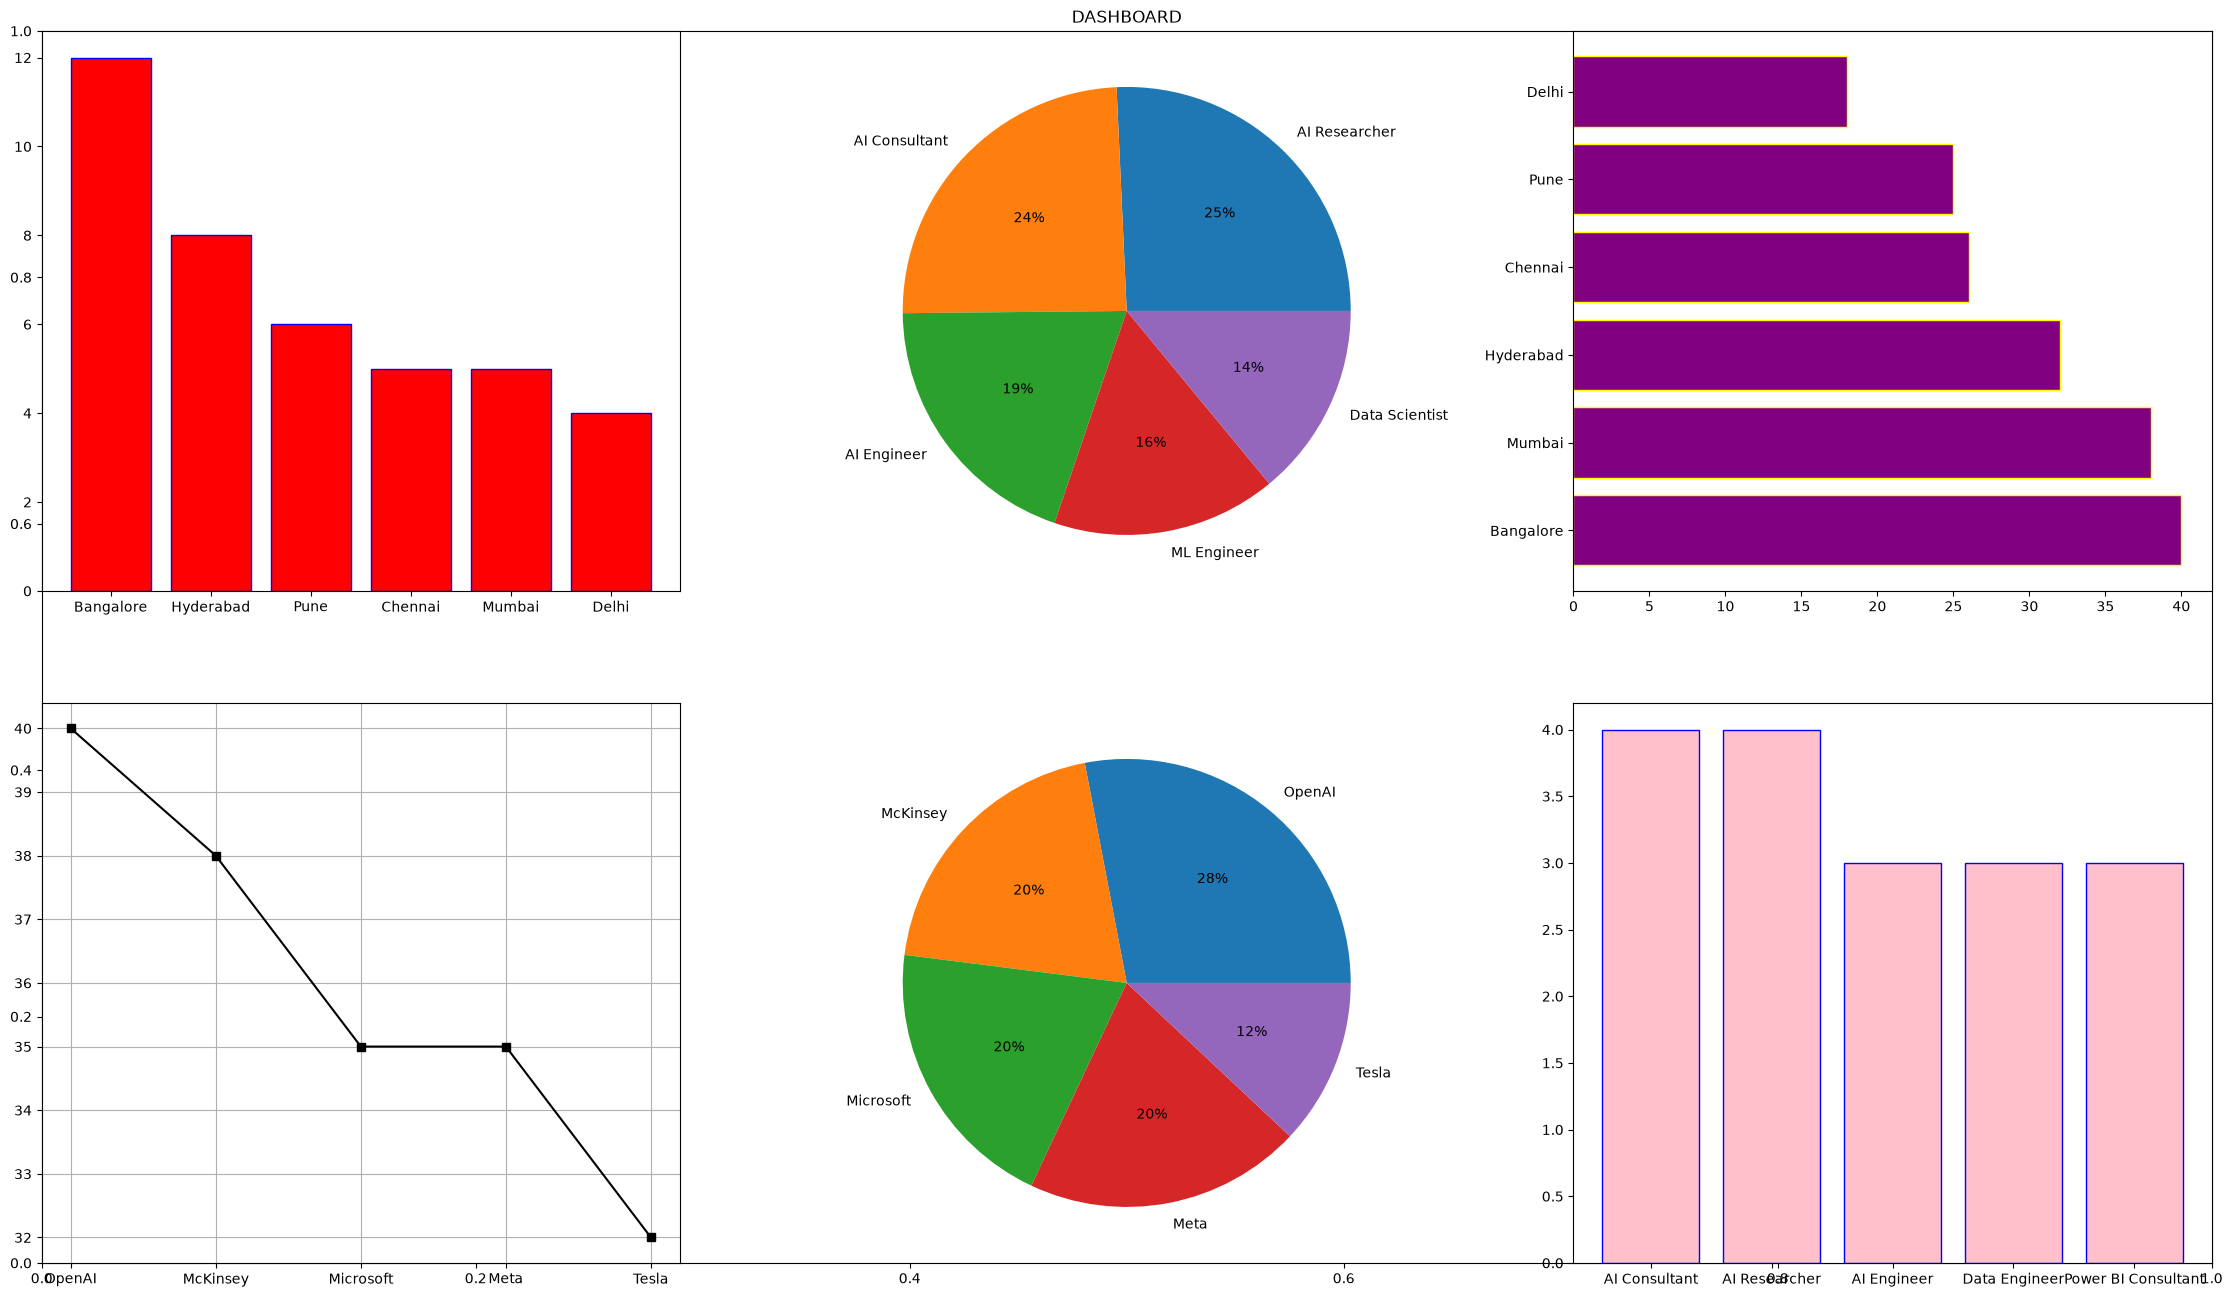

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(28,16))
plt.title("DASHBOARD")
plt.subplot(2,3,1)
plt.bar(a.index,a.values,color="red",edgecolor="blue")
plt.subplot(2,3,2)
plt.pie(b.values,labels=b.index,autopct="%1d%%")
plt.subplot(2,3,3)
plt.barh(c.index,c.values,color="purple",edgecolor="yellow")
plt.subplot(2,3,4)
plt.plot(d.index,d.values,color="black",marker="s")
plt.grid(True)
plt.subplot(2,3,5)
plt.pie(e.values,labels=d.index,autopct="%1d%%")
plt.subplot(2,3,6)
plt.bar(f.index,f.values,color="pink",edgecolor="blue")
plt.show()